In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from pathlib import Path

Confirm the XGBoost model exists

04_model_training.ipynb already has

If the same Jupyter kernel is still running, you may be able to use it directly.

In [8]:
import joblib
from pathlib import Path

MODEL_PATH = Path("../artifacts/models/fraud_xgboost.pkl")

xgb_model = joblib.load(MODEL_PATH)

print(type(xgb_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [9]:
import numpy as np

PROCESSED_DIR = Path("../data/processed")

X_test = np.load(
    PROCESSED_DIR / "X_test_processed.npy"
)

y_test = np.load(
    PROCESSED_DIR / "y_test.npy"
)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (1272524, 12)
y_test: (1272524,)


##### Don't run SHAP on all 1.27 million rows
use a samples

In [10]:
sample_size = 2000

X_shap = X_test[:sample_size]
y_shap = y_test[:sample_size]

print("SHAP sample:", X_shap.shape)

SHAP sample: (2000, 12)


##### Load  preprocessor

In [11]:
preprocessor = joblib.load(
    "../artifacts/preprocessors/preprocessor.pkl"
)

feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__step' 'num__amount' 'num__oldbalanceOrg' 'num__newbalanceOrig'
 'num__oldbalanceDest' 'num__newbalanceDest' 'num__isFlaggedFraud'
 'cat__type_CASH_IN' 'cat__type_CASH_OUT' 'cat__type_DEBIT'
 'cat__type_PAYMENT' 'cat__type_TRANSFER']


##### Now create SHAP explainer

In [12]:
import shap

explainer = shap.TreeExplainer(xgb_model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [13]:
shap_values = explainer.shap_values(X_shap)

print(shap_values.shape)

(2000, 12)


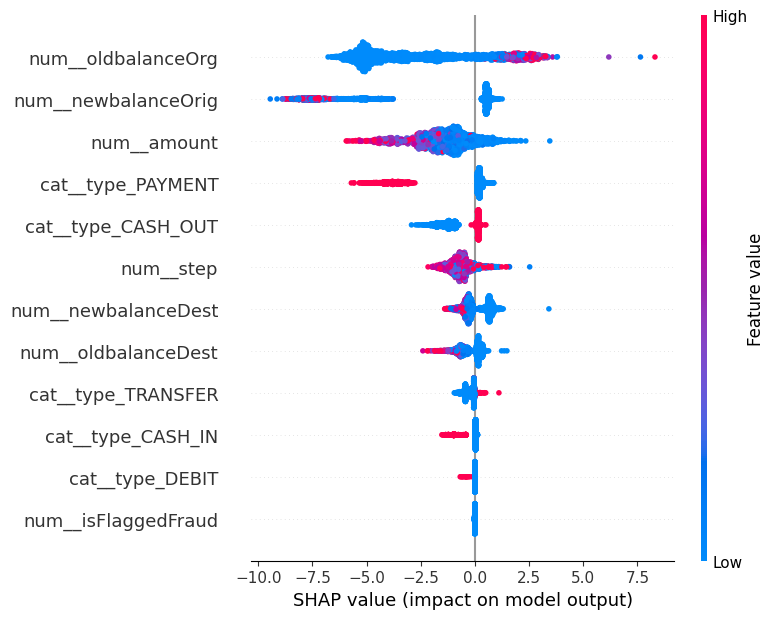

In [14]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.show()

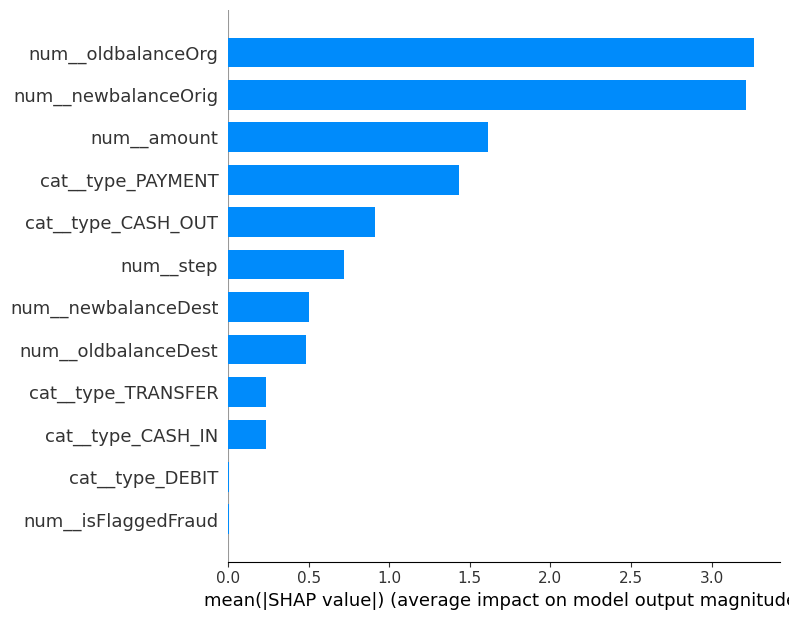

In [15]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()